EXP.NO: 2
PART A - VISUALIZATION OF ACTIVATION FUNCTIONS
Name : Yamini M
Roll No : 24BAD131


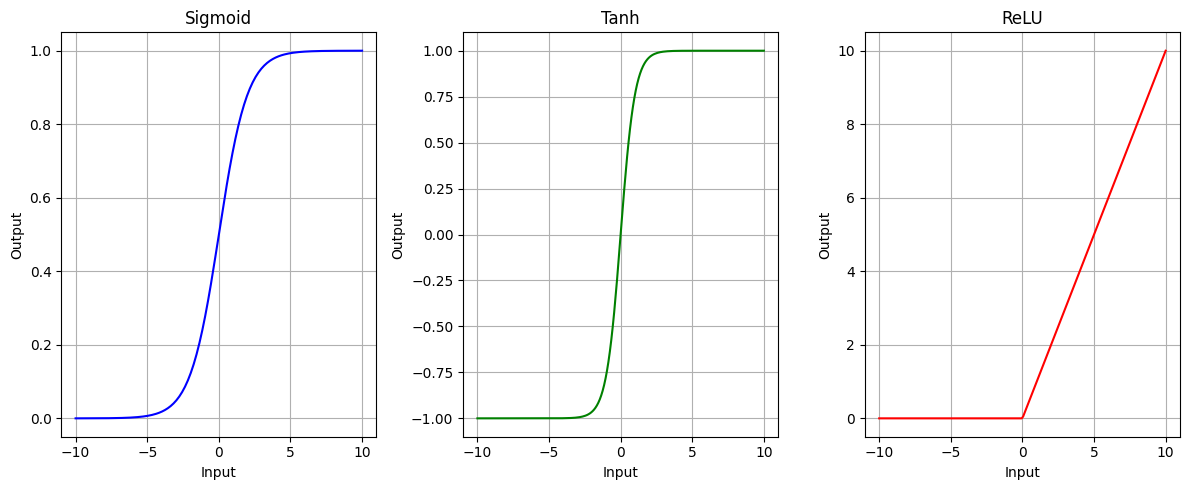


Comparison
-------------------------------------------
Sigmoid
Output Range        : 0 to 1
Saturation Region   : Yes
Gradient Behavior   : Vanishing Gradient
Efficiency          : Slow
Application         : Binary Classification

Tanh
Output Range        : -1 to 1
Saturation Region   : Yes
Gradient Behavior   : Less Vanishing than Sigmoid
Efficiency          : Moderate
Application         : Hidden Layers

ReLU
Output Range        : 0 to Infinity
Saturation Region   : No (Positive Side)
Gradient Behavior   : Fast Learning
Efficiency          : High
Application         : Deep Neural Networks


In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("EXP.NO: 2")
print("PART A - VISUALIZATION OF ACTIVATION FUNCTIONS")
print("Name : Yamini M")
print("Roll No : 24BAD131")

x = np.linspace(-10, 10, 200)

sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.plot(x, sigmoid, color="blue")
plt.title("Sigmoid")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)

plt.subplot(1,3,2)
plt.plot(x, tanh, color="green")
plt.title("Tanh")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)

plt.subplot(1,3,3)
plt.plot(x, relu, color="red")
plt.title("ReLU")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nComparison")
print("Sigmoid")
print("Output Range        : 0 to 1")
print("Saturation Region   : Yes")
print("Gradient Behavior   : Vanishing Gradient")
print("Efficiency          : Slow")
print("Application         : Binary Classification")

print("\nTanh")
print("Output Range        : -1 to 1")
print("Saturation Region   : Yes")
print("Gradient Behavior   : Less Vanishing than Sigmoid")
print("Efficiency          : Moderate")
print("Application         : Hidden Layers")

print("\nReLU")
print("Output Range        : 0 to Infinity")
print("Saturation Region   : No (Positive Side)")
print("Gradient Behavior   : Fast Learning")
print("Efficiency          : High")
print("Application         : Deep Neural Networks")

EXP.NO: 2
PART B - PERFORMANCE COMPARISON OF ACTIVATION FUNCTIONS
Name : Yamini M
Roll No : 24BAD131


/tmp/ipykernel_609/1546926099.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({"M":1,"B":0})



Activation Function : SIGMOID
Training Accuracy   : 0.9505
Validation Accuracy : 0.956
Training Loss       : 0.3438
Validation Loss     : 0.3344
Epochs              : 20


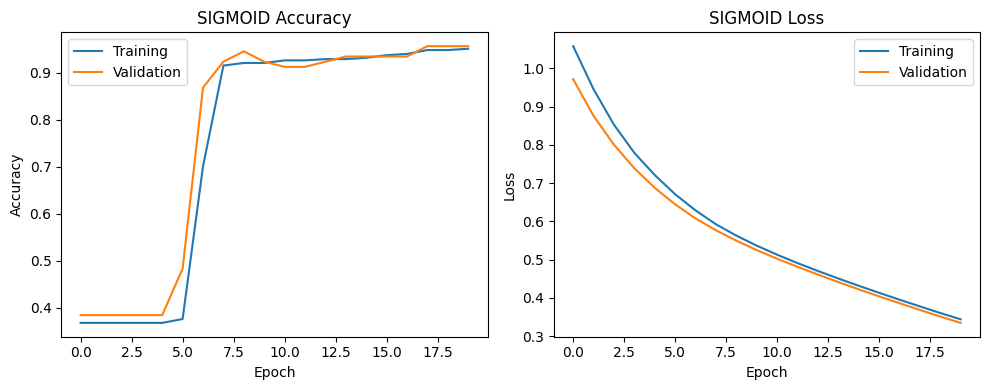


Activation Function : TANH
Training Accuracy   : 0.9918
Validation Accuracy : 0.978
Training Loss       : 0.0534
Validation Loss     : 0.0815
Epochs              : 20


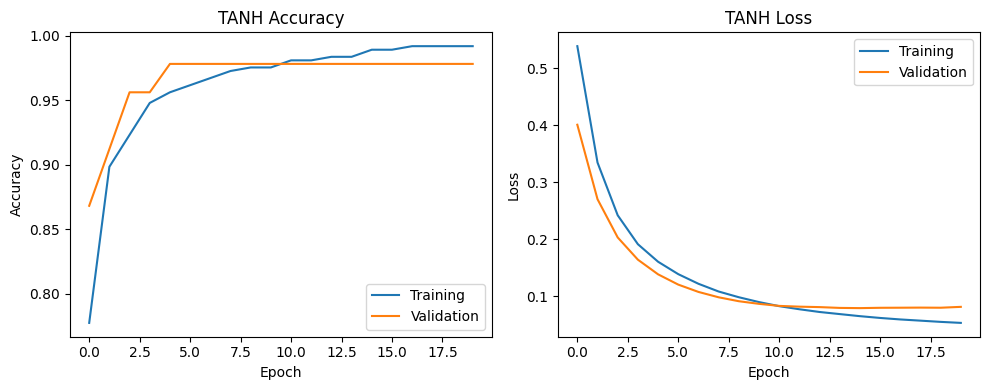


Activation Function : RELU
Training Accuracy   : 0.9918
Validation Accuracy : 0.978
Training Loss       : 0.0541
Validation Loss     : 0.0755
Epochs              : 20


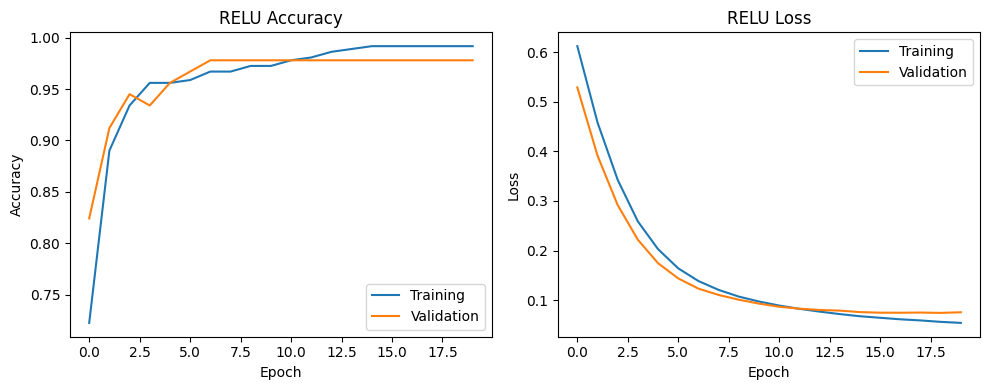


--------------------------------------------
Best Activation Function : TANH
--------------------------------------------


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("EXP.NO: 2")
print("PART B - PERFORMANCE COMPARISON OF ACTIVATION FUNCTIONS")
print("Name : Yamini M")
print("Roll No : 24BAD131")

data = pd.read_csv("brca.csv")

X = data.drop(["Unnamed: 0", "y"], axis=1)
y = data["y"]

X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.mean())

if y.dtype == "object":
    y = y.replace({"M":1,"B":0})

y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

activations = ["sigmoid","tanh","relu"]

results = {}

for act in activations:

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(30,)),
        tf.keras.layers.Dense(32, activation=act),
        tf.keras.layers.Dense(16, activation=act),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    results[act] = {
        "Training Accuracy": history.history["accuracy"][-1],
        "Validation Accuracy": history.history["val_accuracy"][-1],
        "Training Loss": history.history["loss"][-1],
        "Validation Loss": history.history["val_loss"][-1],
        "Epochs": len(history.history["loss"])
    }

    print("\nActivation Function :", act.upper())
    print("Training Accuracy   :", round(results[act]["Training Accuracy"],4))
    print("Validation Accuracy :", round(results[act]["Validation Accuracy"],4))
    print("Training Loss       :", round(results[act]["Training Loss"],4))
    print("Validation Loss     :", round(results[act]["Validation Loss"],4))
    print("Epochs              :", results[act]["Epochs"])

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Training")
    plt.plot(history.history["val_accuracy"], label="Validation")
    plt.title(act.upper()+" Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Training")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.title(act.upper()+" Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

best = max(results, key=lambda x: results[x]["Validation Accuracy"])
print("Best Activation Function :", best.upper())


EXP.NO: 2
PART C - COMPARISON OF OPTIMIZATION ALGORITHMS
Name : Yamini M
Roll No : 24BAD131


/tmp/ipykernel_609/1997869083.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({"M":1,"B":0})



Optimizer : SGD
Training Accuracy   : 0.9451
Validation Accuracy : 0.9341
Training Loss       : 0.2103
Validation Loss     : 0.2246


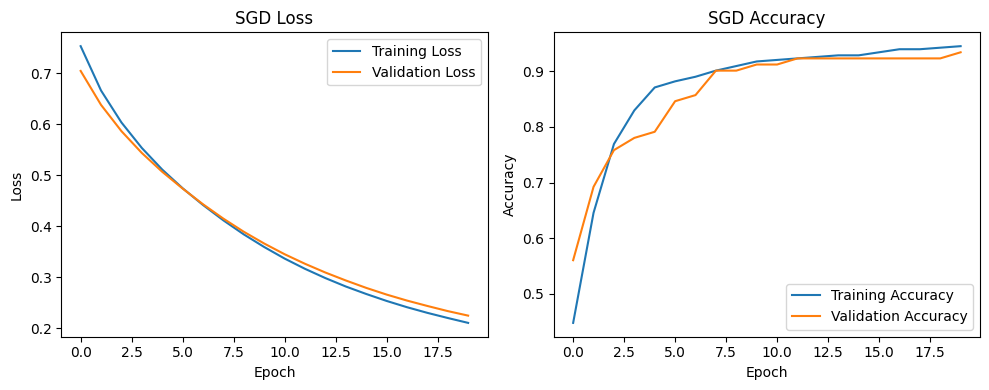


Optimizer : Momentum
Training Accuracy   : 0.9918
Validation Accuracy : 0.967
Training Loss       : 0.0445
Validation Loss     : 0.0822


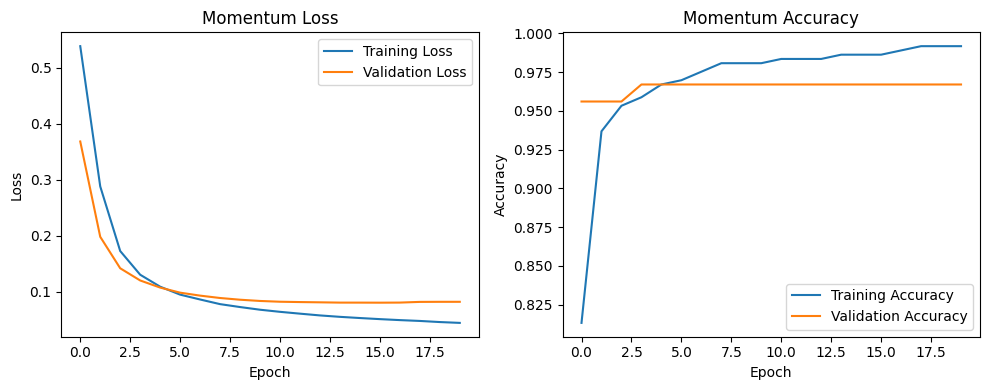


Optimizer : RMSProp
Training Accuracy   : 0.9945
Validation Accuracy : 0.978
Training Loss       : 0.0339
Validation Loss     : 0.0834


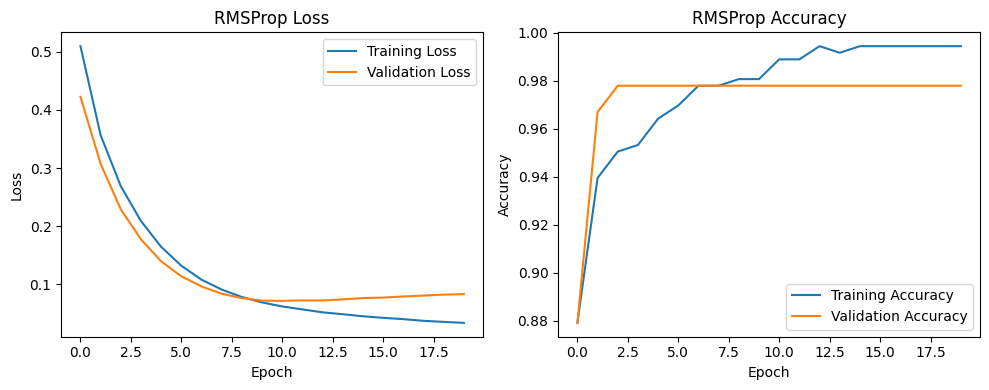


Optimizer : Adam
Training Accuracy   : 0.9945
Validation Accuracy : 0.967
Training Loss       : 0.0474
Validation Loss     : 0.0899


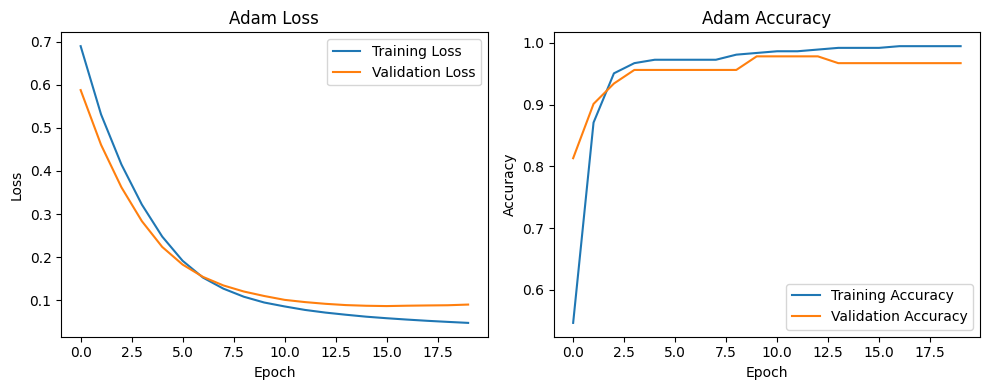


--------------------------------------------
Best Optimizer : RMSProp
--------------------------------------------


In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("EXP.NO: 2")
print("PART C - COMPARISON OF OPTIMIZATION ALGORITHMS")
print("Name : Yamini M")
print("Roll No : 24BAD131")

data = pd.read_csv("brca.csv")

X = data.drop(["Unnamed: 0", "y"], axis=1)
y = data["y"]

X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.mean())

if y.dtype == "object":
    y = y.replace({"M":1,"B":0})

y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

optimizers = {
    "SGD": tf.keras.optimizers.SGD(),
    "Momentum": tf.keras.optimizers.SGD(momentum=0.9),
    "RMSProp": tf.keras.optimizers.RMSprop(),
    "Adam": tf.keras.optimizers.Adam()
}

results = {}

for name, optimizer in optimizers.items():

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(30,)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    results[name] = {
        "Training Accuracy": history.history["accuracy"][-1],
        "Validation Accuracy": history.history["val_accuracy"][-1],
        "Training Loss": history.history["loss"][-1],
        "Validation Loss": history.history["val_loss"][-1]
    }

    print("\nOptimizer :", name)
    print("Training Accuracy   :", round(results[name]["Training Accuracy"],4))
    print("Validation Accuracy :", round(results[name]["Validation Accuracy"],4))
    print("Training Loss       :", round(results[name]["Training Loss"],4))
    print("Validation Loss     :", round(results[name]["Validation Loss"],4))

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(name + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(name + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

best = max(results, key=lambda x: results[x]["Validation Accuracy"])

print("\n--------------------------------------------")
print("Best Optimizer :", best)
print("--------------------------------------------")

In [5]:
from google.colab import drive

drive.mount('/content/drive')

print("EXP.NO:2 PART-D")
print("Yamini M")
print("Roll No:24BAD131")

model.save("/content/drive/MyDrive/ANN_Model.keras")

print("Model saved successfully.")

Mounted at /content/drive
EXP.NO:2 PART-D
Yamini M
Roll No:24BAD131
Model saved successfully.
